# Flujo de Trabajo de Imputación de Contaminación para Pampaneira y Bubión

Este cuaderno ejecuta el pipeline refactorizado para imputar valores faltantes en el conjunto de datos de Pampaneira.

## 1. Configuración e Importaciones

Aseguramos que la raíz del proyecto esté en el path de Python. Ajusta la profundidad del path ('../') según sea necesario dependiendo de dónde se encuentre este cuaderno en relación con la raíz del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import sys
from sklearn.preprocessing import StandardScaler # Mantener para uso directo/verificación potencial
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import SmoothL1Loss

# Asegurar que la raíz del proyecto esté en el Python path
# Ajusta la profundidad del path ('../') según sea necesario
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

Importamos los módulos refactorizados del proyecto:

In [2]:
# Importar módulos refactorizados
from pampaneira_imputation import config
from pampaneira_imputation import data_loader as dl
from pampaneira_imputation import data_preprocessor as dp
from pampaneira_imputation import imputation_methods as im
from pampaneira_imputation import evaluation as ev
from pampaneira_imputation import utils


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



Importamos SAITS por separado (asumiendo que pypots está instalado):

In [3]:
# Importar SAITS por separado (asumiendo que pypots está instalado)
try:
    from pypots.imputation import SAITS, Transformer
except ImportError:
    print("Advertencia: No se encontró la librería pypots. La imputación con SAITS no estará disponible.")
    SAITS = None # Definir como None si no está disponible

Configuramos pandas y la visualización:

In [4]:
# Configurar pandas y visualización
pd.options.mode.chained_assignment = None
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
plt.rcParams["figure.figsize"] = [12, 4]
warnings.filterwarnings("ignore") # Usar con precaución

## 2. Carga de Datos

Cargamos los datos de la intersección (filtrados para PAM_2):

In [5]:
# Cargar datos de intersección (filtrados para PAM_2)
try:
    df_int_raw = dl.load_intersection_data(
        filepath=config.INTERSECTION_FILE,
        target_truck_pos=config.TARGET_TRUCK_POS
    )
    print(f"Forma de los datos de intersección cargados: {df_int_raw.shape}")
    print(f"Rango de fechas: {df_int_raw[config.DATE_COL].min()} a {df_int_raw[config.DATE_COL].max()}")
    # display(df_int_raw.head()) # Opcional: mostrar encabezado
except Exception as e:
    print(f"Error al cargar los datos de intersección: {e}")
    # Detener ejecución o manejar el error apropiadamente
    raise

Forma de los datos de intersección cargados: (1335, 115)
Rango de fechas: 2023-01-17 17:00:00+00:00 a 2023-06-27 00:00:00+00:00


## 3. Preprocesamiento de Datos

### 3.1 Rellenar Marcas de Tiempo Faltantes (Dentro de Periodos Definidos)

Creamos el rango de fechas completo que cubre ambos periodos conocidos de datos del camión:

In [6]:
df_int_reindexed = dp.fill_missing_timestamps(df_int_raw, config.PERIOD_1_START, config.PERIOD_2_END)
print(f"Forma después de reindexar a periodos combinados: {df_int_reindexed.shape}")

Forma después de reindexar a periodos combinados: (3840, 114)


Verificamos los NaNs introducidos por la reindexación:

In [7]:
# Verificar los NaNs introducidos
print(f"NaNs introducidos por reindexación: {df_int_reindexed.isnull().sum().sum()}")

NaNs introducidos por reindexación: 288216


In [8]:
df_int_reindexed

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-01-18 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,NaN,0.0,NaN,NaN,6.6,52.9,3.89,114.50,878.0
2023-01-18 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-26 19:00:00+00:00,7.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0,...,1.5,111.4,7.8,0.6,0.1,31.4,21.5,1.12,246.34,893.3
2023-06-26 20:00:00+00:00,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.4,99.6,23.0,0.3,0.1,28.8,26.0,0.81,7.46,893.6
2023-06-26 21:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,78.8,11.3,0.4,0.1,25.7,29.5,1.06,129.23,893.9
2023-06-26 22:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,77.4,1.9,0.2,0.1,24.7,27.9,1.25,133.45,894.3


### 3.2 Dividir en Periodos

Establecemos la columna de fecha como índice y dividimos el DataFrame en los dos periodos definidos en la configuración.

In [9]:
# Dividir en Periodos
periodo_1_raw, periodo_2_raw = dp.split_by_period(df_int_reindexed)

print(f"Forma del Periodo 1: {periodo_1_raw.shape}")
print(f"Forma del Periodo 2: {periodo_2_raw.shape}")

Forma del Periodo 1: (1344, 114)
Forma del Periodo 2: (480, 114)


In [10]:
periodo_1_raw.loc["2023-03-03 00:00:00":"2023-03-14 23:00:00"]

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-03-03 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,74.6,6.5,0.2,0.1,0.4,57.3,NaN,NaN,888.1
2023-03-03 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-03 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-03 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-03 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-14 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-14 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-14 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-14 22:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

Para dividir el periodo del 18 de enero de 2023 al 14 de marzo de 2023 en entrenamiento, validación y prueba siguiendo un esquema análogo al del Beijing Multi-Site Air-Quality Dataset, vamos a asignar los datos de manera similar a cómo se hizo en ese conjunto.

El esquema original divide los datos en tres partes:

- **Fase de entrenamiento (80% del dataset):** Primeros 45 días
   - **Training:** 80% de los 45 días: 36 días
   - **Validación** 20% restante de los 45 días: 9 días.
- **Prueba (20% del dataset):** 20% del dataset:  12 días.

El periodo de tiempo es del 18 de enero de 2023 al 14 de marzo de 2023. **hay 56 días.**

- **Conjunto de entrenamiento: 18 de enero de 2023 - 21 de febrero de 2023 (35 días)**
- **Conjunto de validación: 22 de febrero de 2023 - 2 de marzo de 2023 (9 días)**.
- **Conjunto de prueba: 3 de marzo de 2023 - 14 de marzo de 2023) (12 días)**



In [11]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data = dp.preprocess_for_imputation(
        periodo_1_raw,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.DataFrame):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Train Start_End: 2023-01-18:2023-02-21
Introduciendo 10.0% de datos faltantes con patrón 'point' (seed=42)...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_X_ori: forma (817, 24, 114)
- val_X_ori: forma (193, 24, 114)
- test_X_ori: forma (265, 24, 114)
- train_X: forma (817, 24, 114)
- val_X: forma (193, 24, 114)
- test_X: forma (265, 24, 114)
- train_index: longitud 840
- val_index: longitud 216
- test_index: longitud 288
- train_preexisting_nan_mask: forma (817, 24, 114)
- val_preexisting_nan_mask: forma (193, 24, 114)
- test_preexisting_nan_mask: forma (265, 24, 114)
- train_indicating_mask: forma (817, 24, 114)
- val_indicating_mask: forma (193, 24, 114)
- test_indicating_mask: forma (265, 24, 114)
- train_artificial_mask: forma (817, 24, 114)
- val_artificial_mask: forma (193, 24, 114)
- test_artificial_mask: forma (265, 24, 114)
- n_train_samples: 817
- n_val_samples: 193
- n_test_samples: 265


Preparamos los conjuntos de datos para PyPOTS (u otras bibliotecas) si es necesario:

In [12]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training = {"X": processed_data['train_X']}
dataset_for_validating = {"X": processed_data['val_X'], "X_ori": processed_data['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing = {
    "X": processed_data['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "artificial_mask": processed_data['test_artificial_mask'] # Máscara de los NaNs introducidos
}

In [13]:
dataset_for_training['X']

array([[[-0.63709506,         nan, -0.42406295, ...,         nan,
         -0.74882624, -3.00781724],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.63709506, -0.66343645, -0.42406295, ...,  2.63524138,
         -0.23911486, -1.39562375],
        [-0.63709506, -0.66343645, -0.42406295, ...,  2.50964231,
          1.47408169, -1.24311896],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.63709506, -0.66343645,         nan, ...,  

### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 2

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

In [14]:
periodo_2_raw

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-06-07 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,88.3,NaN,0.1,0.1,16.7,68.5,2.08,116.29,887.5
2023-06-07 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-26 19:00:00+00:00,7.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0,...,1.5,111.4,7.8,0.6,0.1,31.4,21.5,1.12,246.34,893.3
2023-06-26 20:00:00+00:00,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.4,99.6,23.0,0.3,0.1,28.8,26.0,0.81,7.46,893.6
2023-06-26 21:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,78.8,11.3,0.4,0.1,25.7,29.5,1.06,129.23,893.9
2023-06-26 22:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,77.4,1.9,0.2,0.1,24.7,27.9,1.25,133.45,894.3


### Fechas de división del periodo 2 (20 días)

- 80% del dataset Fase de entrenamiento: 16 días
    - **Training:** 80% de 16: **13 días** (2023-06-07 al 2023-06-19)
    - **Validación:** 20% de 16: **3 días** (2023-06-20 al 2023-06-22)
- 20% del dataset **Testing**: **4 días** (2023-06-23 al 2023-06-26)

In [15]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data2 = dp.preprocess_for_imputation(
        periodo_2_raw,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN,
        train_starn=config.TRAIN_2_START_DATE,
        train_end=config.TRAIN_2_END_DATE,
        val_start=config.VAL_2_START_DATE,
        val_end=config.VAL_2_END_DATE,
        test_start=config.TEST_2_START_DATE,
        test_end=config.TEST_2_END_DATE,
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.DataFrame):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Train Start_End: 2023-01-18:2023-06-19
Introduciendo 10.0% de datos faltantes con patrón 'point' (seed=42)...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_X_ori: forma (817, 24, 114)
- val_X_ori: forma (193, 24, 114)
- test_X_ori: forma (265, 24, 114)
- train_X: forma (817, 24, 114)
- val_X: forma (193, 24, 114)
- test_X: forma (265, 24, 114)
- train_index: longitud 840
- val_index: longitud 216
- test_index: longitud 288
- train_preexisting_nan_mask: forma (817, 24, 114)
- val_preexisting_nan_mask: forma (193, 24, 114)
- test_preexisting_nan_mask: forma (265, 24, 114)
- train_indicating_mask: forma (817, 24, 114)
- val_indicating_mask: forma (193, 24, 114)
- test_indicating_mask: forma (265, 24, 114)
- train_artificial_mask: forma (817, 24, 114)
- val_artificial_mask: forma (193, 24, 114)
- test_artificial_mask: forma (265, 24, 114)
- n_train_samples: 817
- n_val_samples: 193
- n_test_samples: 265


In [16]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training2 = {"X": processed_data2['train_X']}
dataset_for_validating2 = {"X": processed_data2['val_X'], "X_ori": processed_data2['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing2 = {
    "X": processed_data2['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data2['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "artificial_mask" : processed_data2['test_artificial_mask'] # Máscara de los NaNs introducidos
}

## 4. Métodos de Imputación para Periodo 1

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing['X']`). Almacenamos los resultados en un diccionario.

In [17]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing = dataset_for_testing['X']
imputed_results = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 4.1. Modelos Baseline

#### 4.1 Imputación por Mediana

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [18]:
imputed_results['median'] = im.impute_median_sample_wise(X_test_missing)
print(f"Forma imputación mediana: {imputed_results['median'].shape}, NaNs: {np.isnan(imputed_results['median']).sum()}")

  Midiendo tiempo para 'impute_median_sample_wise'...
  Finalizado 'impute_median_sample_wise' en 5.983685 segundos
Forma imputación mediana: (265, 24, 114), NaNs: 0


#### 4.2 Imputación por Media

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [19]:
imputed_results['mean'] = im.impute_mean_sample_wise(X_test_missing)

print(f"Forma imputación media: {imputed_results['mean'].shape}, NaNs: {np.isnan(imputed_results['mean']).sum()}")

  Midiendo tiempo para 'impute_mean_sample_wise'...
  Finalizado 'impute_mean_sample_wise' en 2.235044 segundos
Forma imputación media: (265, 24, 114), NaNs: 0


#### 4.3 Interpolación Lineal

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [20]:

imputed_results['linear'] = im.impute_linear(X_test_missing)
print(f"Forma imputación lineal: {imputed_results['linear'].shape}, NaNs: {np.isnan(imputed_results['linear']).sum()}")

  Midiendo tiempo para 'impute_linear'...
  Finalizado 'impute_linear' en 0.883688 segundos
Forma imputación lineal: (265, 24, 114), NaNs: 0


#### 4.4 Relleno Forward/Backward (ffill/bfill)

Nota: Estos métodos pueden requerir eliminar columnas como `WS`, `WD` si causan problemas o no son necesarias. La función de imputación en sí no elimina columnas, pero la evaluación podría necesitar alineación. Asumiremos por ahora que imputamos todas las características. La evaluación maneja la posible eliminación de columnas. Alternativamente, modificamos los datos de entrada antes de pasarlos a la imputación:

In [21]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing_no_ws_wd = X_test_missing.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing_no_ws_wd = np.delete(X_test_missing, cols_to_drop_indices, axis=2)
else:
    X_test_missing_no_ws_wd = X_test_missing # No hay columnas que eliminar

imputed_results['ffill'] = im.impute_forward(X_test_missing_no_ws_wd)
imputed_results['bfill'] = im.impute_backward(X_test_missing_no_ws_wd)
print(f"Forma imputación Forward fill {imputed_results['ffill'].shape}, NaNs: {np.isnan(imputed_results['ffill']).sum()}")
print(f"Forma imputación Backward fill: {imputed_results['bfill'].shape}, NaNs: {np.isnan(imputed_results['bfill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
  Midiendo tiempo para 'impute_forward'...
  Finalizado 'impute_forward' en 0.066445 segundos
  Midiendo tiempo para 'impute_backward'...
  Finalizado 'impute_backward' en 0.067037 segundos
Forma imputación Forward fill (265, 24, 112), NaNs: 0
Forma imputación Backward fill: (265, 24, 112), NaNs: 0


### Hankel Imputation

In [22]:
imputed_results['hankel'] = imputed_results['mean']
print(f"Forma imputación Hankel: {imputed_results['hankel'].shape}, NaNs: {np.isnan(imputed_results['hankel']).sum()}")

Forma imputación Hankel: (265, 24, 114), NaNs: 0


### 4.5. Modelo Transformer

In [23]:
transformer_model = im.fit_transformer(dataset_for_training, dataset_for_validating)
imputed_results['transformer'] = im.impute_transformer(transformer_model,
                                                       dataset_for_testing)

2025-06-24 18:12:23 [INFO]: No given device, using default device: cpu
2025-06-24 18:12:23 [INFO]: Model files will be saved to ../results/imputation/transformer/20250624_T181223
2025-06-24 18:12:23 [INFO]: Tensorboard file will be saved to ../results/imputation/transformer/20250624_T181223/tensorboard
2025-06-24 18:12:23 [INFO]: Using customized MAE as the training loss function.
2025-06-24 18:12:23 [INFO]: Using customized MSE as the validation metric function.
2025-06-24 18:12:23 [INFO]: Transformer initialized with the given hyperparameters, the number of trainable parameters: 439,922


  Midiendo tiempo para 'fit_transformer'...

---> Ejecutando lógica de imputación con Transformer...
    Inicializando Transformer model...
    Configurando optimizer, scheduler, loss...
    Training Transformer model...


2025-06-24 18:12:24 [INFO]: Epoch 001 - training loss (MAE): 1.2544, validation MSE: 1.0947
2025-06-24 18:12:25 [INFO]: Epoch 002 - training loss (MAE): 0.9350, validation MSE: 1.0613
2025-06-24 18:12:26 [INFO]: Epoch 003 - training loss (MAE): 0.8843, validation MSE: 1.0197
2025-06-24 18:12:27 [INFO]: Epoch 004 - training loss (MAE): 0.8474, validation MSE: 0.9713
2025-06-24 18:12:29 [INFO]: Epoch 005 - training loss (MAE): 0.8094, validation MSE: 0.9012
2025-06-24 18:12:30 [INFO]: Epoch 006 - training loss (MAE): 0.7682, validation MSE: 0.8647
2025-06-24 18:12:32 [INFO]: Epoch 007 - training loss (MAE): 0.7342, validation MSE: 0.8344
2025-06-24 18:12:33 [INFO]: Epoch 008 - training loss (MAE): 0.7093, validation MSE: 0.8145
2025-06-24 18:12:35 [INFO]: Epoch 009 - training loss (MAE): 0.6880, validation MSE: 0.8024
2025-06-24 18:12:36 [INFO]: Epoch 010 - training loss (MAE): 0.6729, validation MSE: 0.7917
2025-06-24 18:12:37 [INFO]: Epoch 011 - training loss (MAE): 0.6572, validation 

    Transformer training complete.
  Finalizado 'fit_transformer' en 48.116869 segundos
  Midiendo tiempo para 'impute_transformer'...
    Imputando con Transformer en el conjunto de test...
    Imputación Transformer completa.
  Finalizado 'impute_transformer' en 0.136193 segundos


### 4.6. Modelo SAITS

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [24]:
saits_model = im.fit_saits(dataset_for_training, dataset_for_validating)
imputed_results['saits'] = im.impute_saits(saits_model,
                                           dataset_for_testing)

2025-06-24 18:13:12 [INFO]: No given device, using default device: cpu
2025-06-24 18:13:12 [INFO]: Model files will be saved to ../results/imputation/saits/20250624_T181312
2025-06-24 18:13:12 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250624_T181312/tensorboard
2025-06-24 18:13:12 [INFO]: Using customized MAE as the training loss function.
2025-06-24 18:13:12 [INFO]: Using customized MSE as the validation metric function.
2025-06-24 18:13:12 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800


  Midiendo tiempo para 'fit_saits'...

Configurando y ejecutando imputación con SAITS...
Entrenando modelo SAITS...


2025-06-24 18:13:15 [INFO]: Epoch 001 - training loss (MAE): 1.1928, validation MSE: 1.1015
2025-06-24 18:13:19 [INFO]: Epoch 002 - training loss (MAE): 0.8962, validation MSE: 1.0610
2025-06-24 18:13:22 [INFO]: Epoch 003 - training loss (MAE): 0.8285, validation MSE: 1.0002
2025-06-24 18:13:25 [INFO]: Epoch 004 - training loss (MAE): 0.7881, validation MSE: 0.9469
2025-06-24 18:13:28 [INFO]: Epoch 005 - training loss (MAE): 0.7483, validation MSE: 0.8795
2025-06-24 18:13:31 [INFO]: Epoch 006 - training loss (MAE): 0.7116, validation MSE: 0.8364
2025-06-24 18:13:34 [INFO]: Epoch 007 - training loss (MAE): 0.6835, validation MSE: 0.8066
2025-06-24 18:13:37 [INFO]: Epoch 008 - training loss (MAE): 0.6637, validation MSE: 0.7755
2025-06-24 18:13:41 [INFO]: Epoch 009 - training loss (MAE): 0.6474, validation MSE: 0.7596
2025-06-24 18:13:45 [INFO]: Epoch 010 - training loss (MAE): 0.6324, validation MSE: 0.7455
2025-06-24 18:13:50 [INFO]: Epoch 011 - training loss (MAE): 0.6199, validation 

Entrenamiento de SAITS completo.
  Finalizado 'fit_saits' en 89.199731 segundos
  Midiendo tiempo para 'impute_saits'...
Imputando con SAITS en el conjunto de test...
  Finalizado 'impute_saits' en 0.381279 segundos


## 4.2. Tiempos de ejecución en Periodo 1

In [25]:
if im.imputation_times:
    # Mapeo de nombres de función a nombres amigables para la tabla final
    # Si los nombres de tus funciones ya son amigables, puedes saltarte esto
    friendly_names_map = {
        'impute_mean': 'Mean',
        'impute_median': 'Median', # Este es el que mostraste
        'impute_linear': 'Linear',
        'impute_forward': 'Forward Fill',
        'impute_backward': 'Backward Fill',
        'impute_hankel' : 'Hankel Imputation',
        'impute_transformer': 'Transformer',
        'impute_saits': 'Saits',
        # Asegúrate de que este mapeo incluye TODAS tus funciones decoradas
    }

    # Usar nombres amigables en la tabla
    table_data = [(friendly_names_map.get(func_name, func_name), duration)
                  for func_name, duration in im.imputation_times.items()]

    time_results_df = pd.DataFrame(table_data, columns=['Método', 'Tiempo (segundos)'])

    # Ordenar por tiempo
    time_results_df = time_results_df.sort_values(by='Tiempo (segundos)').reset_index(drop=True)
time_results_df

,Método,Tiempo (segundos)
0,Forward Fill,0.066445
1,Backward Fill,0.067037
2,Transformer,0.136193
3,Saits,0.381279
4,Linear,0.883688
5,impute_mean_sample_wise,2.235044
6,impute_median_sample_wise,5.983685
7,fit_transformer,48.116869
8,fit_saits,89.199731


## 5. Métodos de Imputación para Periodo 2

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing2['X']`). Almacenamos los resultados en un diccionario.

In [26]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing2 = dataset_for_testing2['X']
imputed_results2 = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 5.1. Modelos Baseline

#### 5.1.1 Imputación por Mediana en Periodo 2

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [27]:
imputed_results2['median'] = im.impute_median_sample_wise(X_test_missing2)
print(f"Forma imputación mediana: {imputed_results2['median'].shape}, NaNs: {np.isnan(imputed_results2['median']).sum()}")

  Midiendo tiempo para 'impute_median_sample_wise'...
  Finalizado 'impute_median_sample_wise' en 0.628399 segundos
Forma imputación mediana: (73, 24, 114), NaNs: 0


#### 5.1.2 Imputación por Media en Periodo 2

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [28]:
imputed_results2['mean'] = im.impute_mean_sample_wise(X_test_missing2)
print(f"Forma imputación media: {imputed_results2['mean'].shape}, NaNs: {np.isnan(imputed_results2['mean']).sum()}")

  Midiendo tiempo para 'impute_mean_sample_wise'...
  Finalizado 'impute_mean_sample_wise' en 0.355528 segundos
Forma imputación media: (73, 24, 114), NaNs: 0


#### 5.1.3 Interpolación Lineal en Periodo 2

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [29]:
imputed_results2['linear'] = im.impute_linear(X_test_missing2)
print(f"Forma imputación lineal: {imputed_results2['linear'].shape}, NaNs: {np.isnan(imputed_results2['linear']).sum()}")

  Midiendo tiempo para 'impute_linear'...
  Finalizado 'impute_linear' en 0.416150 segundos
Forma imputación lineal: (73, 24, 114), NaNs: 0


#### 5.1.4 Relleno Forward/Backward (ffill/bfill) en Periodo 2


In [30]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing2_no_ws_wd = X_test_missing2.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing2_no_ws_wd = np.delete(X_test_missing2, cols_to_drop_indices, axis=2)
else:
    X_test_missing2_no_ws_wd = X_test_missing2 # No hay columnas que eliminar

imputed_results2['ffill'] = im.impute_forward(X_test_missing2_no_ws_wd)
imputed_results2['bfill'] = im.impute_backward(X_test_missing2_no_ws_wd)
print(f"Forma imputación Forward fill {imputed_results2['ffill'].shape}, NaNs: {np.isnan(imputed_results2['ffill']).sum()}")
print(f"Forma imputación Backward fill: {imputed_results2['bfill'].shape}, NaNs: {np.isnan(imputed_results2['bfill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
  Midiendo tiempo para 'impute_forward'...
  Finalizado 'impute_forward' en 0.039200 segundos
  Midiendo tiempo para 'impute_backward'...
  Finalizado 'impute_backward' en 0.032620 segundos
Forma imputación Forward fill (73, 24, 112), NaNs: 0
Forma imputación Backward fill: (73, 24, 112), NaNs: 0


In [31]:
print(dataset_for_training2['X'].shape)
print(dataset_for_validating2['X'].shape)
print(dataset_for_testing['X'].shape)

(289, 24, 114)
(49, 24, 114)
(265, 24, 114)


### Imputación Hankel

In [32]:
imputed_results2['hankel'] = imputed_results2['mean']
print(f"Forma imputación Hankel: {imputed_results2['hankel'].shape}, NaNs: {np.isnan(imputed_results2['hankel']).sum()}")

Forma imputación Hankel: (73, 24, 114), NaNs: 0


### 5.2. Modelo Transformer

In [33]:
transformer_model2 = im.fit_transformer(dataset_for_training2, dataset_for_validating2)
imputed_results2['transformer'] = im.impute_transformer(transformer_model2,
                                                       dataset_for_testing2)

2025-06-24 18:14:43 [INFO]: No given device, using default device: cpu
2025-06-24 18:14:43 [INFO]: Model files will be saved to ../results/imputation/transformer/20250624_T181443
2025-06-24 18:14:43 [INFO]: Tensorboard file will be saved to ../results/imputation/transformer/20250624_T181443/tensorboard
2025-06-24 18:14:43 [INFO]: Using customized MAE as the training loss function.
2025-06-24 18:14:43 [INFO]: Using customized MSE as the validation metric function.
2025-06-24 18:14:43 [INFO]: Transformer initialized with the given hyperparameters, the number of trainable parameters: 439,922


  Midiendo tiempo para 'fit_transformer'...

---> Ejecutando lógica de imputación con Transformer...
    Inicializando Transformer model...
    Configurando optimizer, scheduler, loss...
    Training Transformer model...


2025-06-24 18:14:43 [INFO]: Epoch 001 - training loss (MAE): 1.5246, validation MSE: 0.6753
2025-06-24 18:14:44 [INFO]: Epoch 002 - training loss (MAE): 1.2096, validation MSE: 0.5329
2025-06-24 18:14:45 [INFO]: Epoch 003 - training loss (MAE): 1.0520, validation MSE: 0.5045
2025-06-24 18:14:46 [INFO]: Epoch 004 - training loss (MAE): 0.9907, validation MSE: 0.4894
2025-06-24 18:14:47 [INFO]: Epoch 005 - training loss (MAE): 0.9731, validation MSE: 0.4894
2025-06-24 18:14:48 [INFO]: Epoch 006 - training loss (MAE): 0.9588, validation MSE: 0.4805
2025-06-24 18:14:48 [INFO]: Epoch 007 - training loss (MAE): 0.9419, validation MSE: 0.4850
2025-06-24 18:14:49 [INFO]: Epoch 008 - training loss (MAE): 0.9297, validation MSE: 0.4767
2025-06-24 18:14:50 [INFO]: Epoch 009 - training loss (MAE): 0.9135, validation MSE: 0.4670
2025-06-24 18:14:50 [INFO]: Epoch 010 - training loss (MAE): 0.8964, validation MSE: 0.4631
2025-06-24 18:14:51 [INFO]: Epoch 011 - training loss (MAE): 0.8791, validation 

    Transformer training complete.
  Finalizado 'fit_transformer' en 37.607768 segundos
  Midiendo tiempo para 'impute_transformer'...
    Imputando con Transformer en el conjunto de test...
    Imputación Transformer completa.
  Finalizado 'impute_transformer' en 0.104394 segundos


### 5.3. Modelo SAITS

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [34]:
saits_model2 = im.fit_saits(dataset_for_training2, dataset_for_validating2)
imputed_results2['saits'] = im.impute_saits(saits_model2,
                                           dataset_for_testing2)

2025-06-24 18:15:21 [INFO]: No given device, using default device: cpu
2025-06-24 18:15:21 [INFO]: Model files will be saved to ../results/imputation/saits/20250624_T181521
2025-06-24 18:15:21 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250624_T181521/tensorboard
2025-06-24 18:15:21 [INFO]: Using customized MAE as the training loss function.
2025-06-24 18:15:21 [INFO]: Using customized MSE as the validation metric function.
2025-06-24 18:15:21 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800


  Midiendo tiempo para 'fit_saits'...

Configurando y ejecutando imputación con SAITS...
Entrenando modelo SAITS...


2025-06-24 18:15:23 [INFO]: Epoch 001 - training loss (MAE): 1.4395, validation MSE: 0.6802
2025-06-24 18:15:24 [INFO]: Epoch 002 - training loss (MAE): 1.2085, validation MSE: 0.5307
2025-06-24 18:15:26 [INFO]: Epoch 003 - training loss (MAE): 1.0616, validation MSE: 0.4983
2025-06-24 18:15:27 [INFO]: Epoch 004 - training loss (MAE): 0.9877, validation MSE: 0.4916
2025-06-24 18:15:28 [INFO]: Epoch 005 - training loss (MAE): 0.9442, validation MSE: 0.4759
2025-06-24 18:15:30 [INFO]: Epoch 006 - training loss (MAE): 0.9265, validation MSE: 0.4789
2025-06-24 18:15:31 [INFO]: Epoch 007 - training loss (MAE): 0.9110, validation MSE: 0.4717
2025-06-24 18:15:33 [INFO]: Epoch 008 - training loss (MAE): 0.8867, validation MSE: 0.4690
2025-06-24 18:15:35 [INFO]: Epoch 009 - training loss (MAE): 0.8675, validation MSE: 0.4609
2025-06-24 18:15:37 [INFO]: Epoch 010 - training loss (MAE): 0.8505, validation MSE: 0.4604
2025-06-24 18:15:38 [INFO]: Epoch 011 - training loss (MAE): 0.8386, validation 

Entrenamiento de SAITS completo.
  Finalizado 'fit_saits' en 71.452524 segundos
  Midiendo tiempo para 'impute_saits'...
Imputando con SAITS en el conjunto de test...
  Finalizado 'impute_saits' en 0.185004 segundos


## 5.2. Tiempos de ejecución en Periodo 2

In [35]:

if im.imputation_times:
    # Mapeo de nombres de función a nombres amigables para la tabla final
    # Si los nombres de tus funciones ya son amigables, puedes saltarte esto
    friendly_names_map = {
        'impute_mean': 'Mean',
        'impute_median': 'Median', # Este es el que mostraste
        'impute_linear': 'Linear',
        'impute_forward': 'Forward Fill',
        'impute_backward': 'Backward Fill',
        'impute_hankel' :  'Hankel Imputation',
        'fit_transformer': 'Fit Transformer',
        'impute_transformer': 'Transformer',
        'fit_saits':    'Fit Saits',
        'impute_saits': 'Saits',
        # Asegúrate de que este mapeo incluye TODAS tus funciones decoradas
    }

    # Usar nombres amigables en la tabla
    table_data = [(friendly_names_map.get(func_name, func_name), duration)
                  for func_name, duration in im.imputation_times.items()]

    time_results_df2 = pd.DataFrame(table_data, columns=['Método', 'Tiempo (segundos)'])

    # Ordenar por tiempo
    time_results_df2 = time_results_df.sort_values(by='Tiempo (segundos)').reset_index(drop=True)
time_results_df2

,Método,Tiempo (segundos)
0,Forward Fill,0.066445
1,Backward Fill,0.067037
2,Transformer,0.136193
3,Saits,0.381279
4,Linear,0.883688
5,impute_mean_sample_wise,2.235044
6,impute_median_sample_wise,5.983685
7,fit_transformer,48.116869
8,fit_saits,89.199731


## 6. Evaluar Resultados de Imputación en Periodo 1

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `artificials_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [36]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")
import importlib
import pampaneira_imputation.evaluation as ev

# Recargar el módulo
importlib.reload(ev)

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table = ev.evaluate_all_methods(
    processed_data,
    imputed_results
)

evaluation_table.T


Evaluando rendimiento de imputación en el conjunto de test...

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ffill debido a columnas eliminadas para ffill.

Calculando métricas para: ffill
Ajustando datos verdaderos y máscara para bfill debido a columnas eliminadas para bfill.

Calculando métricas para: bfill

Calculando métricas para: hankel

Calculando métricas para: transformer

Calculando métricas para: saits


Method,Median,Mean,Linear,Ffill,Bfill,Hankel,Transformer,Saits
RMSE,1.1457,1.0576,0.8790,1.0496,1.0558,1.0576,0.6599,0.6479
MSE,1.3126,1.1185,0.7727,1.1017,1.1148,1.1185,0.4355,0.4198
MAE,0.6977,0.7365,0.4638,0.5603,0.5601,0.7365,0.3411,0.3370
MRE,0.9395,0.9917,0.6245,0.7544,0.7542,0.9917,0.4593,0.4538


### 6.1. Interpretación de la Tabla de Métricas de Imputación/Predicción

Esta tabla compara el rendimiento de diferentes métodos de imputación o predicción utilizando cuatro métricas de error: RMSE (Raíz del Error Cuadrático Medio), MSE (Error Cuadrático Medio), MAE (Error Absoluto Medio) y MRE (Error Relativo Medio). Valores más bajos en todas las métricas indican un mejor rendimiento.

En resumen, los métodos basados en modelos complejos, Transformer y Saits, demuestran el mejor rendimiento general, con valores significativamente más bajos en todas las métricas en comparación con los métodos más simples.

La Media se destaca como un método de referencia sorprendentemente efectivo, superando a la Mediana y a los métodos de interpolación lineal y de relleno simple (Ffill y Bfill). Esto sugiere que para este conjunto de datos, la media proporciona una buena estimación central.

Los métodos de relleno simple, Ffill (relleno hacia adelante) y Bfill (relleno hacia atrás), muestran el peor rendimiento, indicando que son enfoques ingenuos y menos efectivos para este tipo de datos.

El método Lineal se sitúa en un punto intermedio, mejor que los rellenos simples pero peor que la Media, la Mediana y los modelos Transformer y Saits.

## 7. Evaluar Resultados de Imputación en Periodo 2

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `artificial_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [37]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table2 = ev.evaluate_all_methods(
    processed_data2,
    imputed_results2,
    methods_to_evaluate=list(imputed_results2.keys()) # Evaluar todos los métodos calculados
)

evaluation_table2.T


Evaluando rendimiento de imputación en el conjunto de test...

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ffill debido a columnas eliminadas para ffill.

Calculando métricas para: ffill
Ajustando datos verdaderos y máscara para bfill debido a columnas eliminadas para bfill.

Calculando métricas para: bfill

Calculando métricas para: hankel

Calculando métricas para: transformer

Calculando métricas para: saits


Method,Median,Mean,Linear,Ffill,Bfill,Hankel,Transformer,Saits
RMSE,1.0979,1.0484,0.9112,1.0604,1.0848,1.0484,0.7298,0.7180
MSE,1.2053,1.0991,0.8302,1.1243,1.1769,1.0991,0.5326,0.5156
MAE,0.7100,0.7553,0.4858,0.5772,0.5825,0.7553,0.4009,0.3871
MRE,0.9154,0.9739,0.6264,0.7464,0.7534,0.9739,0.5169,0.4991


In [38]:
dataset_for_testing.keys()

dict_keys(['X', 'X_ori', 'artificial_mask'])

## 8. Visualizar Resultados (Ejemplo: NO2)

Visualizamos los resultados de la imputación para una característica específica (NO2) en el periodo de test. Comparamos la serie original (escalada, con valores faltantes), la serie verdadera (`Ground Truth`, escalada, antes de introducir valores faltantes artificiales) y las series imputadas por diferentes métodos. Los puntos rojos indican los valores que fueron artificialmente marcados como faltantes y luego imputados.


--- Generando gráfico para: NO2 ---


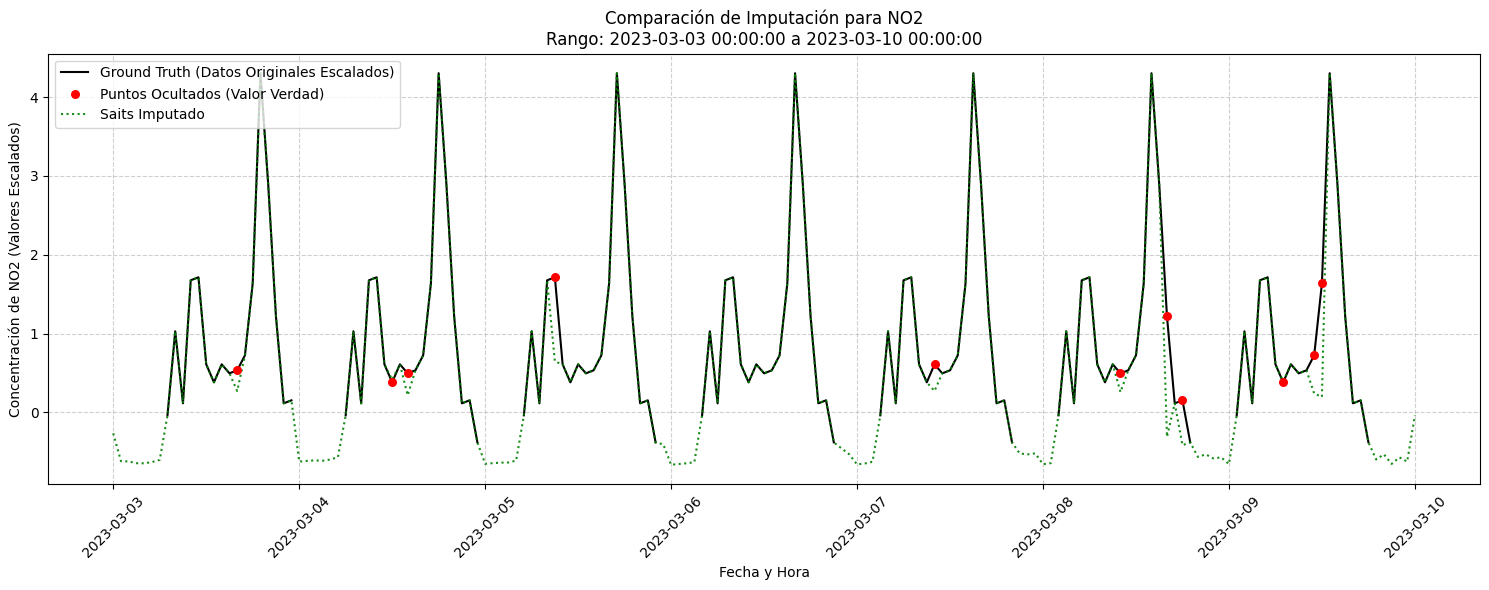


--- Generando gráfico para: PM10 ---


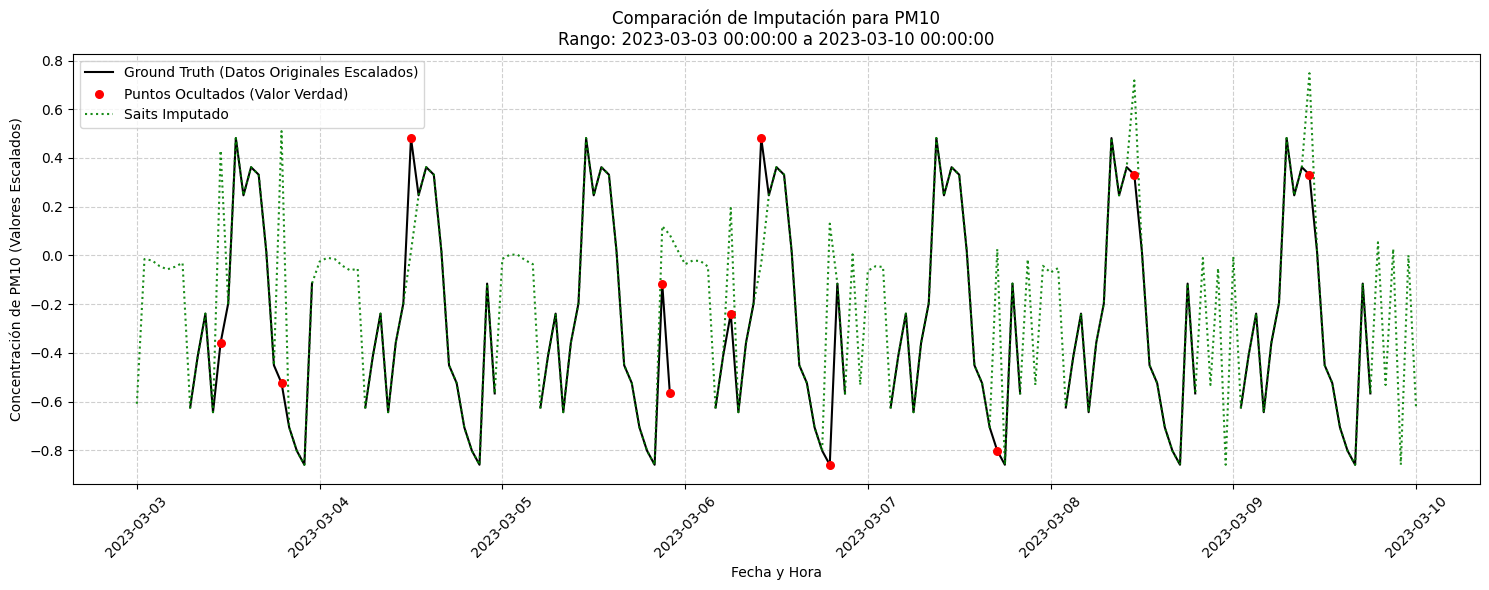


--- Generando gráfico para: O3 ---


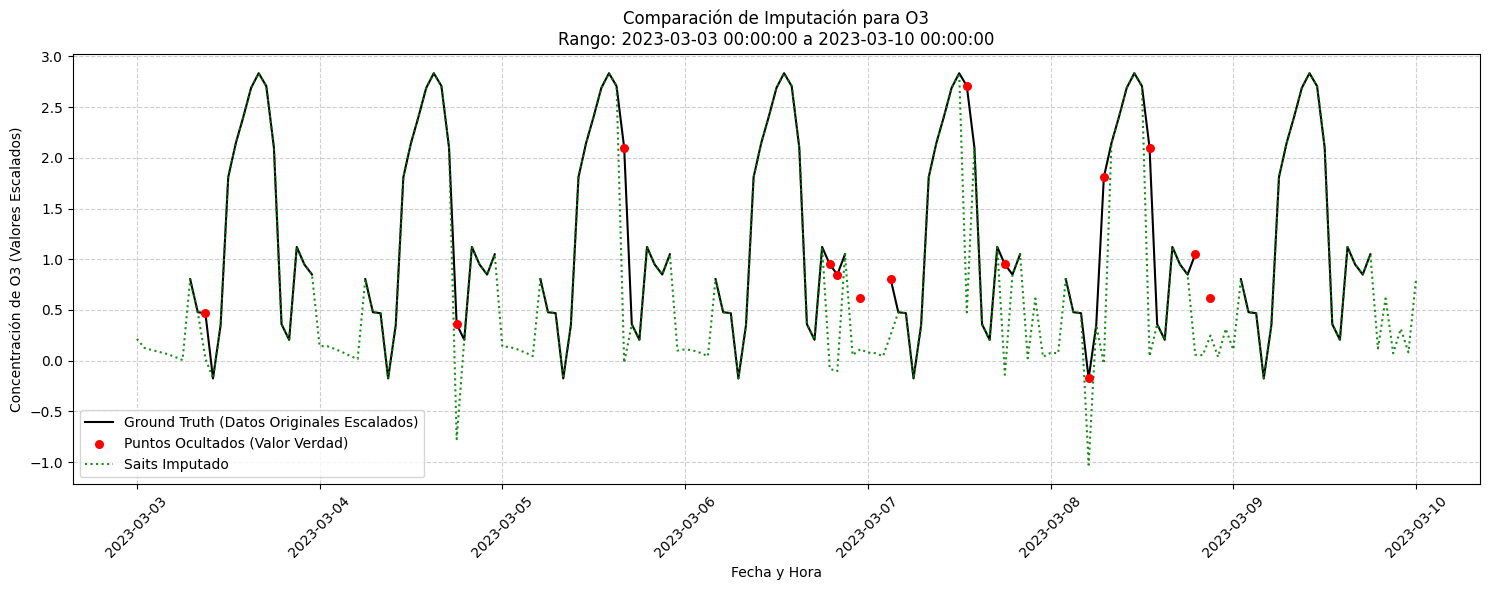


--- Generando gráfico para: eBC_ff ---


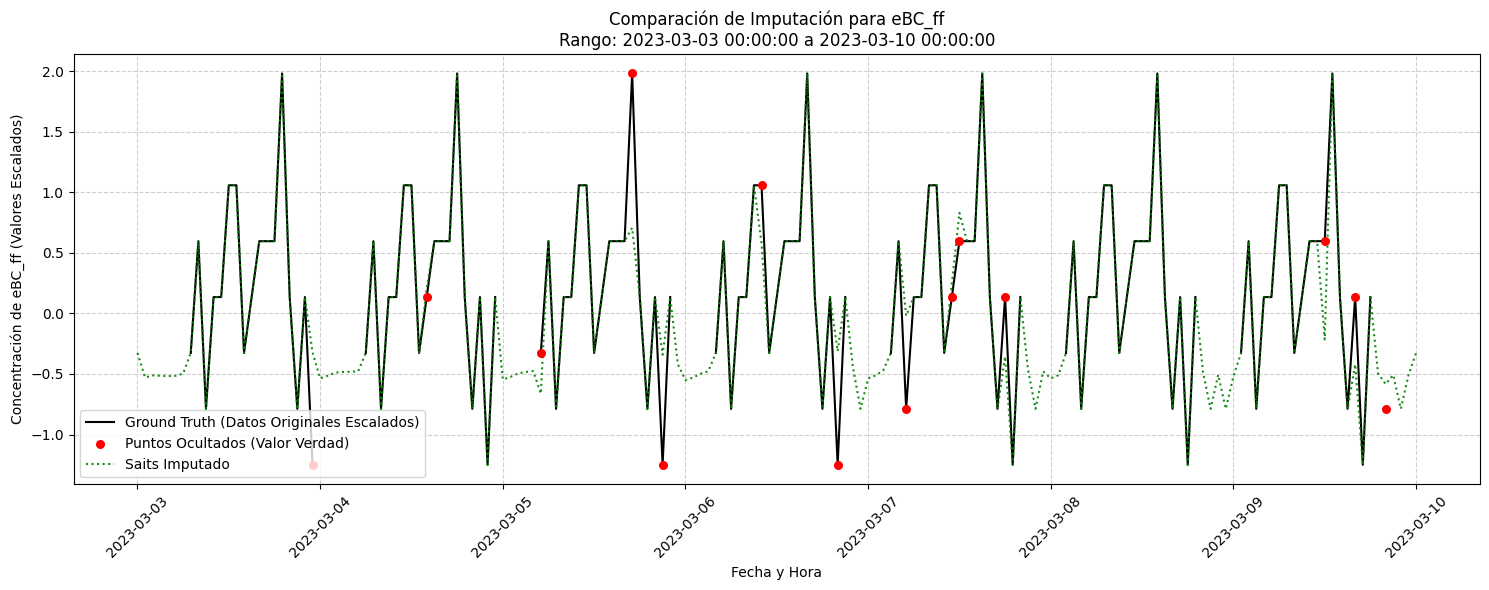


--- Generando gráfico para: TEMP ---


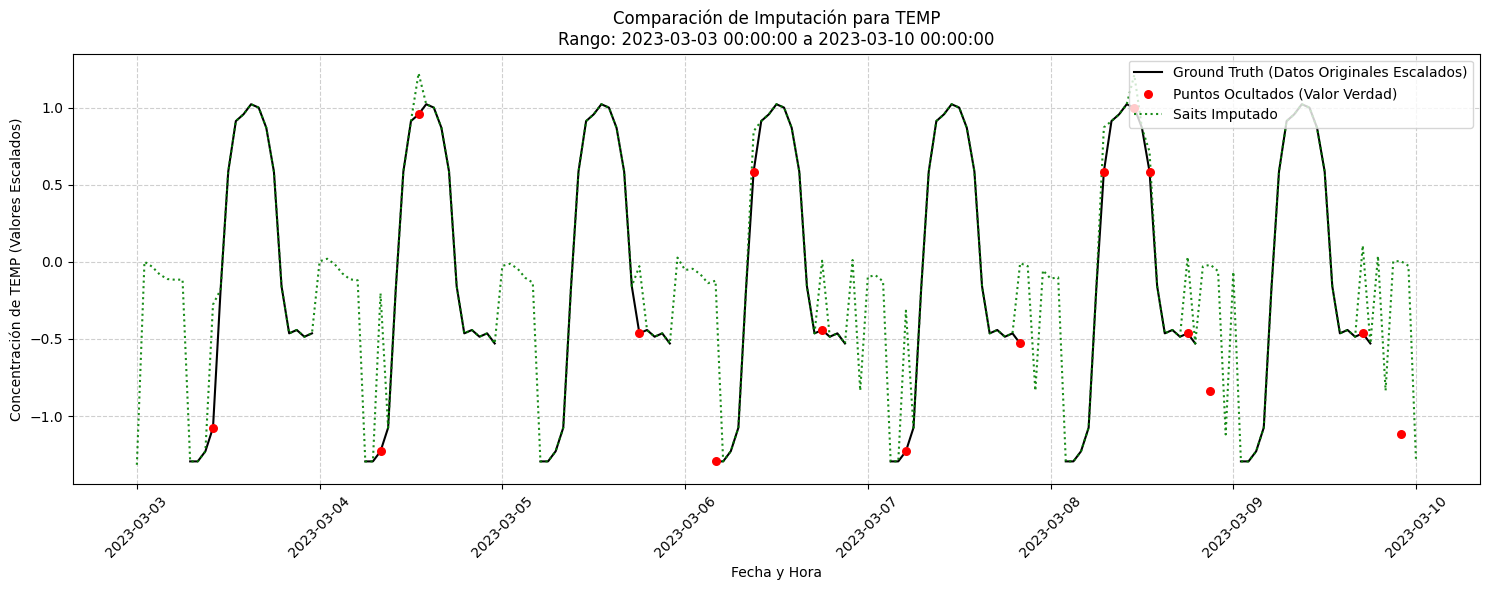

In [40]:
# --- Inicio del Código Refactorizado ---

VARIABLES_A_PLOTEAR = ["NO2", "PM10", "O3", "eBC_ff", "TEMP"]
PLOT_START_DATE = "2023-03-03 00:00:00" # Rango de fechas para el zoom
PLOT_END_DATE = "2023-03-10 00:00:00"   # Reducido para mejor visualización
IMPUTATION_METHOD_TO_PLOT = 'saits'
IMPUTED_COLOR = 'green'
IMPUTED_LINESTYLE = ':'

def plot_imputation_comparison_for_feature(
    feature_to_plot,
    plot_start_str,
    plot_end_str,
    config_obj,
    original_data_df, # periodo_1_raw
    processed_data_dict, # processed_data
    imputed_results_dict, # imputed_results
    test_data_dict, # dataset_for_testing
    utils_obj,
    method_key='saits',
    imputed_color='green',
    imputed_linestyle=':'
):
    """
    Genera un gráfico comparando el ground truth (con puntos donde se imputó)
    y los resultados de un método de imputación para una característica específica.

    Args:
        feature_to_plot (str): Nombre de la característica a plotear.
        plot_start_str (str): Fecha de inicio del plot (e.g., "YYYY-MM-DD HH:MM:SS").
        plot_end_str (str): Fecha de fin del plot.
        config_obj (object): Objeto de configuración con FEATURE_COLUMNS, N_STEPS.
        original_data_df (pd.DataFrame): DataFrame con los datos originales completos (periodo_1_raw).
                                          Su índice debe ser un DatetimeIndex.
        processed_data_dict (dict): Diccionario con 'test_index', 'n_features'.
                                     'test_index' es el DatetimeIndex de los datos de test.
        imputed_results_dict (dict): Diccionario donde las claves son nombres de métodos
                                     y los valores son los arrays de datos imputados.
        test_data_dict (dict): Diccionario con 'X_ori' (ground truth ventaneado)
                               y 'artificial_mask'.
        utils_obj (object): Objeto con el método 'reshape_imputed_to_df'.
        method_key (str): Clave del método de imputación en imputed_results_dict.
        imputed_color (str): Color para la línea de datos imputados.
        imputed_linestyle (str): Estilo de línea para datos imputados.
    """
    if feature_to_plot not in config_obj.FEATURE_COLUMNS:
        print(f"Advertencia: '{feature_to_plot}' no está en config.FEATURE_COLUMNS. Saltando gráfico.")
        return

    feature_index = config_obj.FEATURE_COLUMNS.index(feature_to_plot)

    # El índice para reconstruir los datos ventaneados ('X_ori', 'imputed_results')
    # debe ser el índice de los datos de test sobre los que se generaron esas ventanas.
    # Asumimos que es processed_data_dict['test_index'].
    reconstruction_index = processed_data_dict['test_index']

    # --- 1. Ground Truth (desde X_ori, que son los datos ANTES de enmascarar para test) ---
    ground_truth_df_full = utils_obj.reshape_imputed_to_df(
        test_data_dict['X_ori'],
        reconstruction_index,
        config_obj.FEATURE_COLUMNS,
        config_obj.N_STEPS
    )

    # Filtrar por el rango de fechas deseado para el plot
    try:
        ground_truth_series_plot_range = ground_truth_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]
    except KeyError:
        print(f"Advertencia para '{feature_to_plot}': El rango de fechas {plot_start_str} a {plot_end_str} no se encontró completamente en los datos de ground truth reconstruidos. Saltando plot de ground truth.")
        ground_truth_series_plot_range = pd.Series(dtype='float64') # Serie vacía para evitar errores

    if ground_truth_series_plot_range.empty:
        print(f"No hay datos de ground truth para {feature_to_plot} en el rango especificado.")
        # Considerar no continuar si el ground truth no está.
        # return # Opcional: salir si no hay ground truth

    # --- 2. Marcar Puntos que Fueron Artificialmente Ocultados (usando la máscara) ---
    # La máscara 'artificial_mask' se aplica sobre 'X_ori'.
    # Su forma es (n_windows, n_steps, n_features). Hay que aplanarla y alinearla con ground_truth_df_full.
    mask_reshaped_flat = test_data_dict['artificial_mask'].reshape(-1, processed_data_dict['n_features'])

    # Crear una Serie para la máscara de la característica actual, usando el mismo índice que ground_truth_df_full
    # Esto asume que el orden y longitud de mask_reshaped_flat coincide con ground_truth_df_full
    if len(mask_reshaped_flat) == len(ground_truth_df_full):
        mask_series_full_feature = pd.Series(
            mask_reshaped_flat[:, feature_index],
            index=ground_truth_df_full.index
        )
        mask_series_plot_range = mask_series_full_feature.loc[plot_start_str:plot_end_str]
        missing_indices_in_plot_range = mask_series_plot_range[mask_series_plot_range == 1].index
    else:
        print(f"Advertencia para '{feature_to_plot}': Discrepancia de longitud entre máscara aplanada ({len(mask_reshaped_flat)}) y ground_truth_df_full ({len(ground_truth_df_full)}). No se marcarán puntos faltantes.")
        missing_indices_in_plot_range = pd.Index([])


    # --- 3. Graficar Resultados Imputados para el método elegido ---
    imputed_series_plot_range = pd.Series(dtype='float64') # Inicializar como vacía
    if method_key in imputed_results_dict:
        y_pred_method = imputed_results_dict[method_key]
        #FEATURES_fbfill = [feature for feature in config.FEATURE_COLUMNS if feature not in ('WS', 'WD')]
        imputed_df_full = utils_obj.reshape_imputed_to_df(
            y_pred_method,
            reconstruction_index, # Mismo índice de reconstrucción
            config_obj.FEATURE_COLUMNS,
            config_obj.N_STEPS
        )
        try:
            imputed_series_plot_range = imputed_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]
        except KeyError:
            print(f"Advertencia para '{feature_to_plot}': El rango de fechas {plot_start_str} a {plot_end_str} no se encontró completamente en los datos imputados ({method_key}).")
            # imputed_series_plot_range permanece vacía
    else:
        print(f"Advertencia: El método '{method_key}' no se encuentra en imputed_results_dict.")

    # --- 4. Crear el Gráfico ---
    plt.figure(figsize=(15, 6))

    # Plotear Ground Truth (si existe en el rango)
    if not ground_truth_series_plot_range.empty:
        plt.plot(ground_truth_series_plot_range.index, ground_truth_series_plot_range.values,
                 label='Ground Truth (Datos Originales Escalados)',
                 color='black',
                 linewidth=1.5)

        # Plotear los puntos rojos donde los valores fueron artificialmente ocultados (y luego imputados)
        # Asegurar que los missing_indices existan en ground_truth_series_plot_range antes de graficar
        valid_missing_indices = missing_indices_in_plot_range.intersection(ground_truth_series_plot_range.index)
        if not valid_missing_indices.empty:
            plt.scatter(valid_missing_indices, ground_truth_series_plot_range.loc[valid_missing_indices],
                        color='red',
                        s=30,
                        label='Puntos Ocultados (Valor Verdad)',
                        zorder=5) # Dibujar encima

    # Plotear Datos Imputados (si existen en el rango)
    if not imputed_series_plot_range.empty:
        plt.plot(imputed_series_plot_range.index, imputed_series_plot_range.values,
                 label=f'{method_key.title()} Imputado',
                 color=imputed_color,
                 linestyle=imputed_linestyle,
                 alpha=0.9)
    else:
        print(f"No hay datos imputados para {feature_to_plot} con el método {method_key} en el rango especificado.")


    plt.title(f"Comparación de Imputación para {feature_to_plot}\nRango: {plot_start_str} a {plot_end_str}")
    plt.xlabel("Fecha y Hora")
    # Aquí asumimos que los datos están escalados. Si los des-escalas, cambia la etiqueta.
    plt.ylabel(f"Concentración de {feature_to_plot} (Valores Escalados)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# --- Bucle para generar los gráficos para las variables seleccionadas ---
for feature in VARIABLES_A_PLOTEAR:
    print(f"\n--- Generando gráfico para: {feature} ---")
    plot_imputation_comparison_for_feature(
        feature_to_plot=feature,
        plot_start_str=PLOT_START_DATE,
        plot_end_str=PLOT_END_DATE,
        config_obj=config,
        original_data_df=periodo_1_raw, # Usado para el índice completo si es necesario, pero reconstruction_index es más directo
        processed_data_dict=processed_data,
        imputed_results_dict=imputed_results,
        test_data_dict=dataset_for_testing,
        utils_obj=utils,
        method_key=IMPUTATION_METHOD_TO_PLOT,
        imputed_color=IMPUTED_COLOR,
        imputed_linestyle=IMPUTED_LINESTYLE
    )

## Diferencia de Puntos


--- Generando gráfico para: NO2 ---


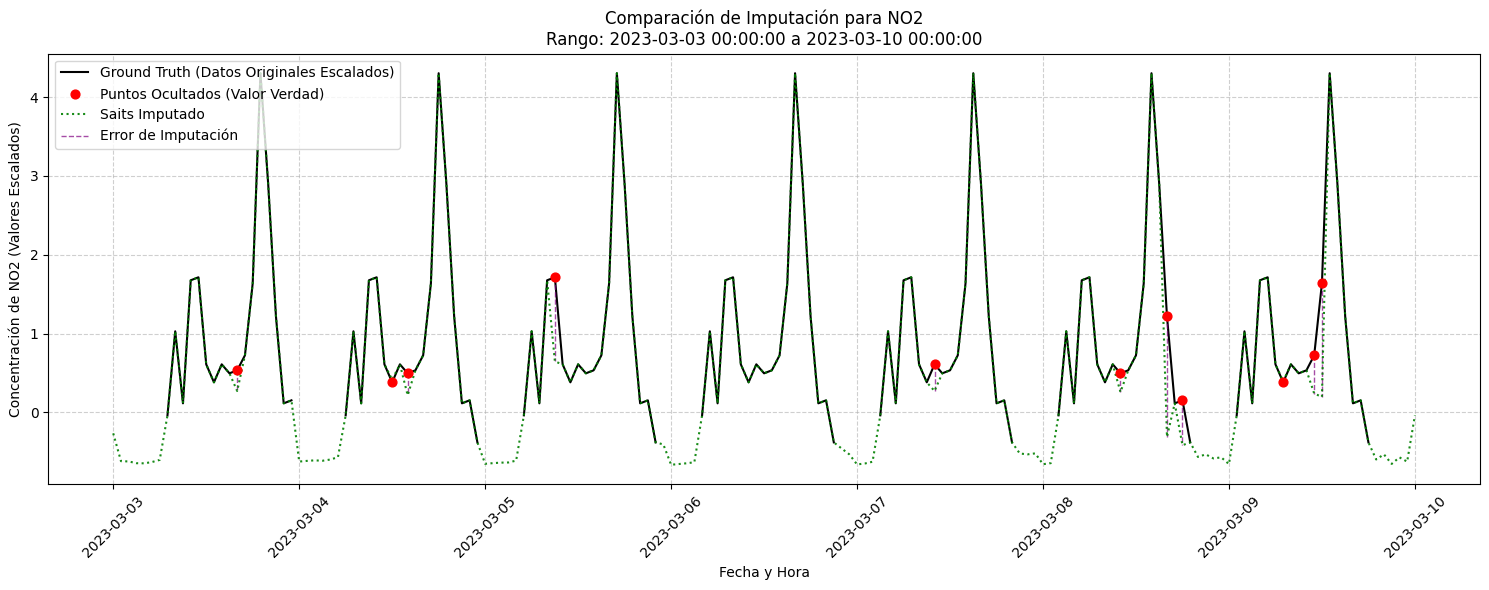


--- Generando gráfico para: PM10 ---


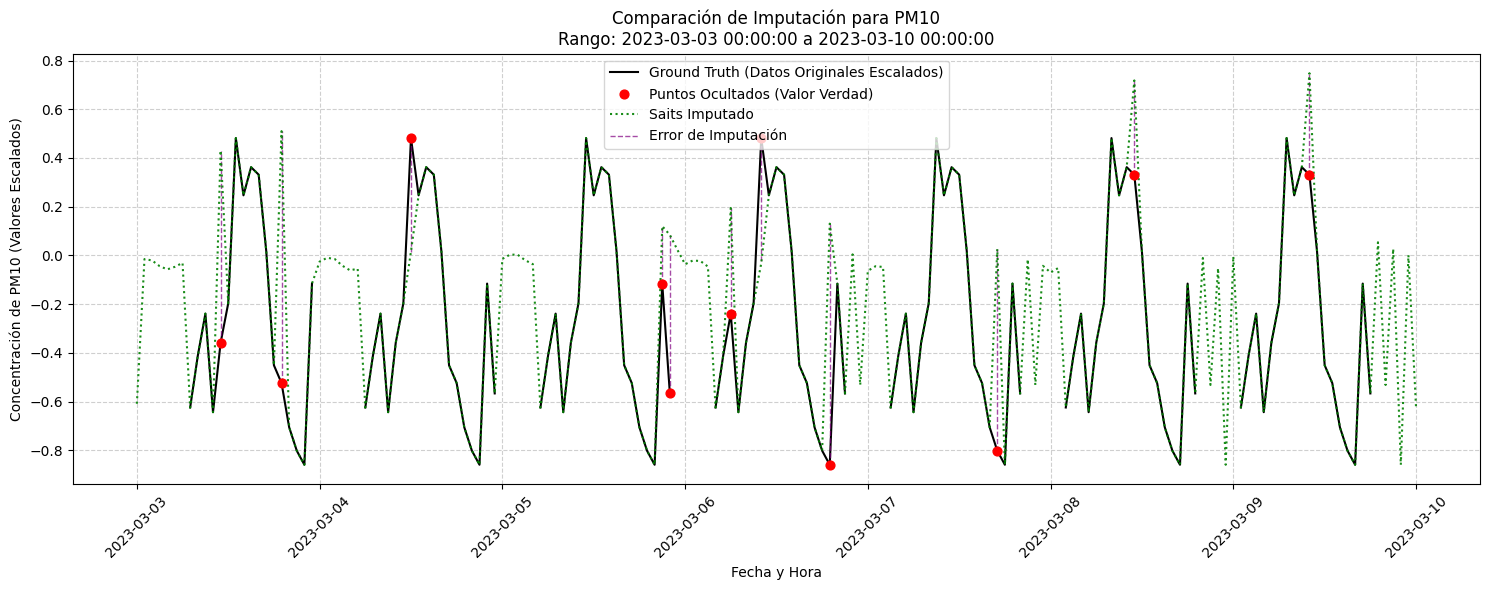


--- Generando gráfico para: O3 ---


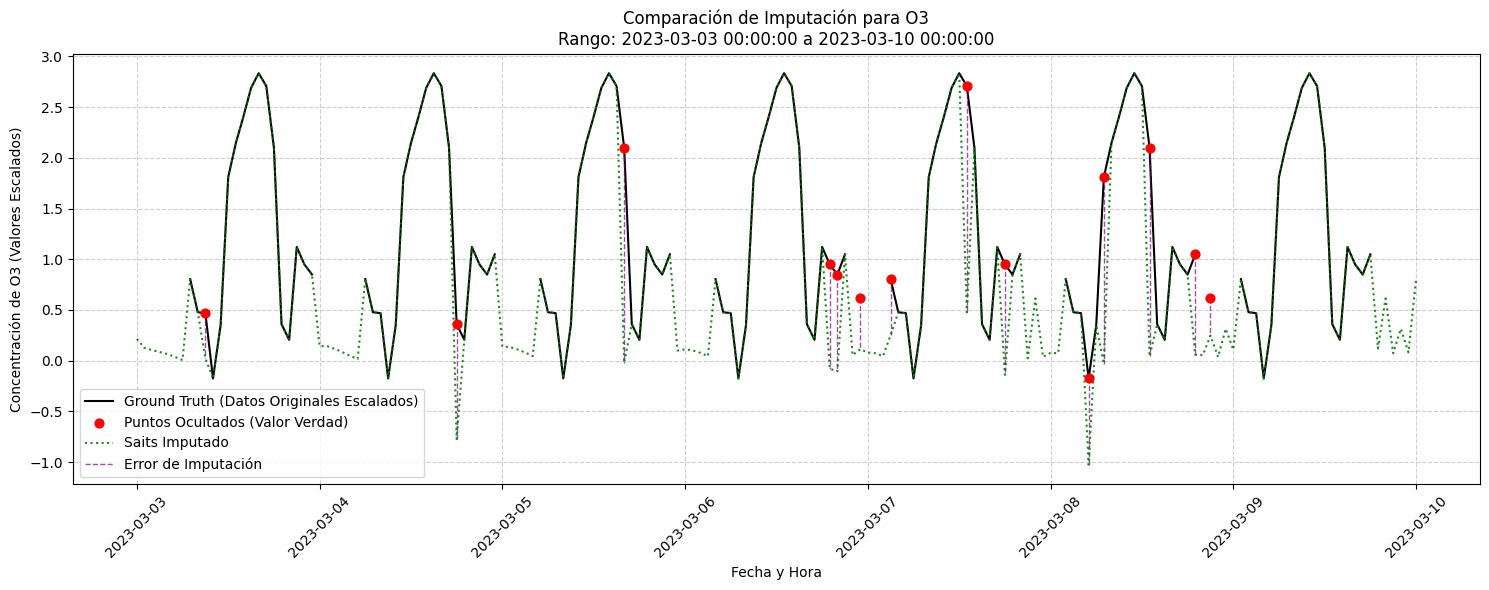


--- Generando gráfico para: eBC_ff ---


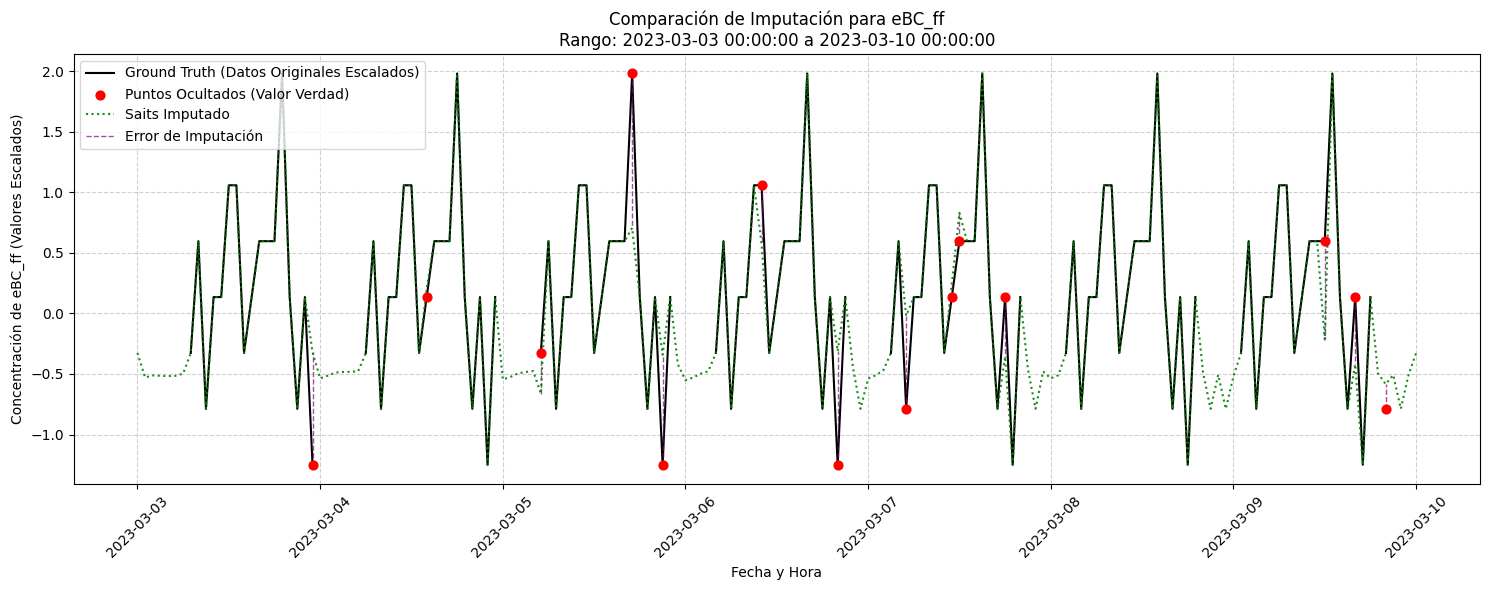


--- Generando gráfico para: TEMP ---


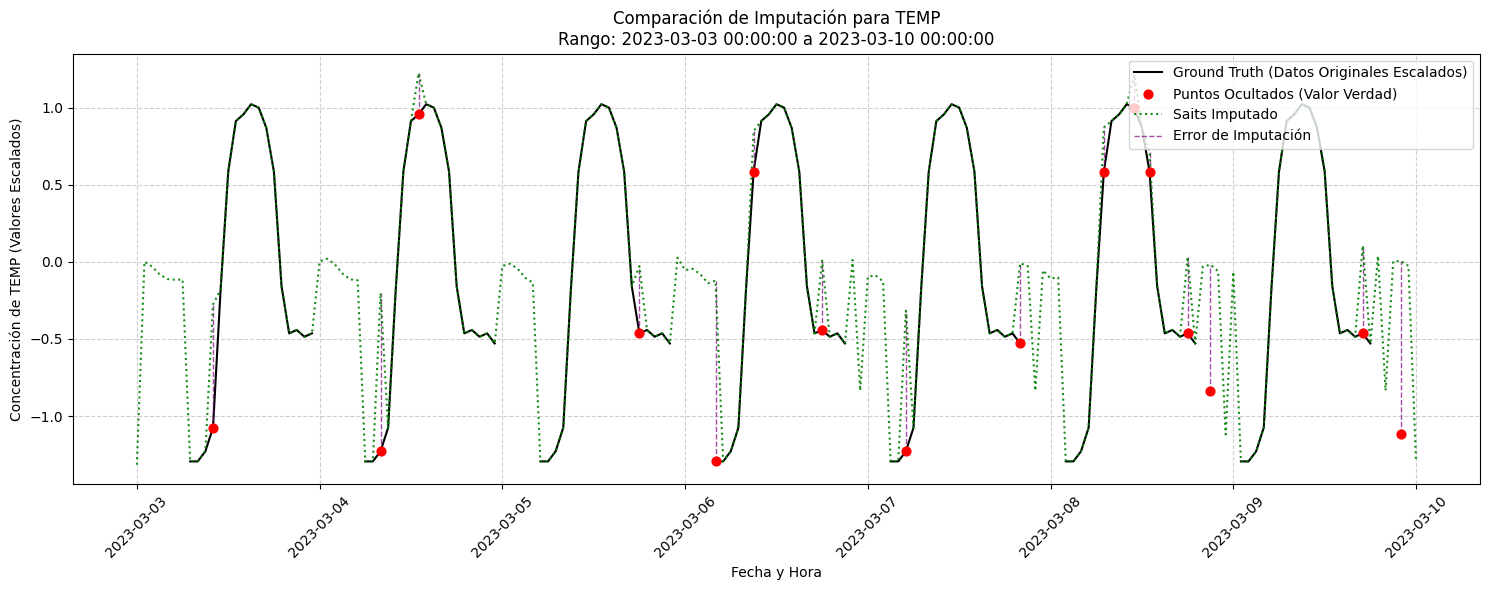

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Inicio del Código Refactorizado ---

VARIABLES_A_PLOTEAR = ["NO2", "PM10", "O3", "eBC_ff", "TEMP"]
PLOT_START_DATE = "2023-03-03 00:00:00" # Rango de fechas para el zoom
PLOT_END_DATE = "2023-03-10 00:00:00"   # Reducido para mejor visualización
IMPUTATION_METHOD_TO_PLOT = 'saits'
IMPUTED_COLOR = 'green'
IMPUTED_LINESTYLE = ':'

def plot_imputation_comparison_for_feature(
    feature_to_plot,
    plot_start_str,
    plot_end_str,
    config_obj,
    original_data_df, # periodo_1_raw
    processed_data_dict, # processed_data
    imputed_results_dict, # imputed_results
    test_data_dict, # dataset_for_testing
    utils_obj,
    method_key='saits',
    imputed_color='green',
    imputed_linestyle=':'
):
    """
    Genera un gráfico comparando el ground truth (con puntos donde se imputó),
    los resultados de un método de imputación y el error entre ambos para una
    característica específica.

    Args:
        feature_to_plot (str): Nombre de la característica a plotear.
        plot_start_str (str): Fecha de inicio del plot (e.g., "YYYY-MM-DD HH:MM:SS").
        plot_end_str (str): Fecha de fin del plot.
        config_obj (object): Objeto de configuración con FEATURE_COLUMNS, N_STEPS.
        original_data_df (pd.DataFrame): DataFrame con los datos originales completos (periodo_1_raw).
                                          Su índice debe ser un DatetimeIndex.
        processed_data_dict (dict): Diccionario con 'test_index', 'n_features'.
                                     'test_index' es el DatetimeIndex de los datos de test.
        imputed_results_dict (dict): Diccionario donde las claves son nombres de métodos
                                     y los valores son los arrays de datos imputados.
        test_data_dict (dict): Diccionario con 'X_ori' (ground truth ventaneado)
                               y 'artificial_mask'.
        utils_obj (object): Objeto con el método 'reshape_imputed_to_df'.
        method_key (str): Clave del método de imputación en imputed_results_dict.
        imputed_color (str): Color para la línea de datos imputados.
        imputed_linestyle (str): Estilo de línea para datos imputados.
    """
    if feature_to_plot not in config_obj.FEATURE_COLUMNS:
        print(f"Advertencia: '{feature_to_plot}' no está en config.FEATURE_COLUMNS. Saltando gráfico.")
        return

    feature_index = config_obj.FEATURE_COLUMNS.index(feature_to_plot)

    # El índice para reconstruir los datos ventaneados ('X_ori', 'imputed_results')
    reconstruction_index = processed_data_dict['test_index']

    # --- 1. Ground Truth (desde X_ori, datos ANTES de enmascarar) ---
    ground_truth_df_full = utils_obj.reshape_imputed_to_df(
        test_data_dict['X_ori'], reconstruction_index, config_obj.FEATURE_COLUMNS, config_obj.N_STEPS
    )
    try:
        ground_truth_series_plot_range = ground_truth_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]
    except KeyError:
        print(f"Advertencia para '{feature_to_plot}': El rango de fechas no se encontró en los datos de ground truth. Saltando plot.")
        ground_truth_series_plot_range = pd.Series(dtype='float64')

    if ground_truth_series_plot_range.empty:
        print(f"No hay datos de ground truth para {feature_to_plot} en el rango especificado.")

    # --- 2. Marcar Puntos que Fueron Artificialmente Ocultados ---
    mask_reshaped_flat = test_data_dict['artificial_mask'].reshape(-1, processed_data_dict['n_features'])
    missing_indices_in_plot_range = pd.Index([])
    if len(mask_reshaped_flat) == len(ground_truth_df_full):
        mask_series_full_feature = pd.Series(mask_reshaped_flat[:, feature_index], index=ground_truth_df_full.index)
        mask_series_plot_range = mask_series_full_feature.loc[plot_start_str:plot_end_str]
        missing_indices_in_plot_range = mask_series_plot_range[mask_series_plot_range == 1].index
    else:
        print(f"Advertencia para '{feature_to_plot}': Discrepancia de longitud entre máscara y datos. No se marcarán puntos faltantes.")

    # --- 3. Obtener Resultados Imputados para el método elegido ---
    imputed_series_plot_range = pd.Series(dtype='float64')
    if method_key in imputed_results_dict:
        y_pred_method = imputed_results_dict[method_key]
        imputed_df_full = utils_obj.reshape_imputed_to_df(
            y_pred_method, reconstruction_index, config_obj.FEATURE_COLUMNS, config_obj.N_STEPS
        )
        try:
            imputed_series_plot_range = imputed_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]
        except KeyError:
            print(f"Advertencia para '{feature_to_plot}': El rango de fechas no se encontró en los datos imputados ({method_key}).")
    else:
        print(f"Advertencia: El método '{method_key}' no se encuentra en imputed_results_dict.")

    # --- 4. Crear el Gráfico ---
    plt.figure(figsize=(15, 6))

    # Plotear Ground Truth (si existe en el rango)
    if not ground_truth_series_plot_range.empty:
        plt.plot(ground_truth_series_plot_range.index, ground_truth_series_plot_range.values,
                 label='Ground Truth (Datos Originales Escalados)', color='black', linewidth=1.5)

        valid_missing_indices = missing_indices_in_plot_range.intersection(ground_truth_series_plot_range.index)
        if not valid_missing_indices.empty:
            plt.scatter(valid_missing_indices, ground_truth_series_plot_range.loc[valid_missing_indices],
                        color='red', s=40, label='Puntos Ocultados (Valor Verdad)', zorder=5)

    # Plotear Datos Imputados (si existen en el rango)
    if not imputed_series_plot_range.empty:
        plt.plot(imputed_series_plot_range.index, imputed_series_plot_range.values,
                 label=f'{method_key.title()} Imputado', color=imputed_color,
                 linestyle=imputed_linestyle, alpha=0.9, zorder=4)

    # --- 5. DIBUJAR LÍNEAS DE ERROR VERTICALES (NUEVO CÓDIGO) ---
    # Esta sección conecta los puntos rojos (valor verdad) con el valor imputado correspondiente.
    if not imputed_series_plot_range.empty and not valid_missing_indices.empty:
        # Asegurarnos de que los índices de los puntos imputados también estén en el rango
        valid_imputed_indices = valid_missing_indices.intersection(imputed_series_plot_range.index)

        is_first_error_line = True # Para añadir la etiqueta a la leyenda solo una vez
        for idx in valid_imputed_indices:
            y_true = ground_truth_series_plot_range.loc[idx]
            y_imputed = imputed_series_plot_range.loc[idx]

            # Definir la etiqueta solo para la primera línea para evitar duplicados en la leyenda
            label = 'Error de Imputación' if is_first_error_line else None

            # Dibujar la línea vertical desde el valor verdadero hasta el imputado
            plt.plot([idx, idx], [y_true, y_imputed],
                     color='purple',
                     linestyle='--',
                     linewidth=1,
                     alpha=0.7,
                     label=label,
                     zorder=3)
            is_first_error_line = False

    # --- Finalización del Gráfico ---
    plt.title(f"Comparación de Imputación para {feature_to_plot}\nRango: {plot_start_str} a {plot_end_str}")
    plt.xlabel("Fecha y Hora")
    plt.ylabel(f"Concentración de {feature_to_plot} (Valores Escalados)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# --- Bucle para generar los gráficos para las variables seleccionadas ---
# (Asegúrate de que las variables config, periodo_1_raw, processed_data,
# imputed_results, dataset_for_testing y utils estén definidas en tu notebook)

for feature in VARIABLES_A_PLOTEAR:
    print(f"\n--- Generando gráfico para: {feature} ---")
    plot_imputation_comparison_for_feature(
        feature_to_plot=feature,
        plot_start_str=PLOT_START_DATE,
        plot_end_str=PLOT_END_DATE,
        config_obj=config,
        original_data_df=periodo_1_raw,
        processed_data_dict=processed_data,#
        imputed_results_dict=imputed_results,
        test_data_dict=dataset_for_testing,
        utils_obj=utils,
        method_key=IMPUTATION_METHOD_TO_PLOT,
        imputed_color=IMPUTED_COLOR,
        imputed_linestyle=IMPUTED_LINESTYLE
    )


--- Generando gráfico para: NO2 ---


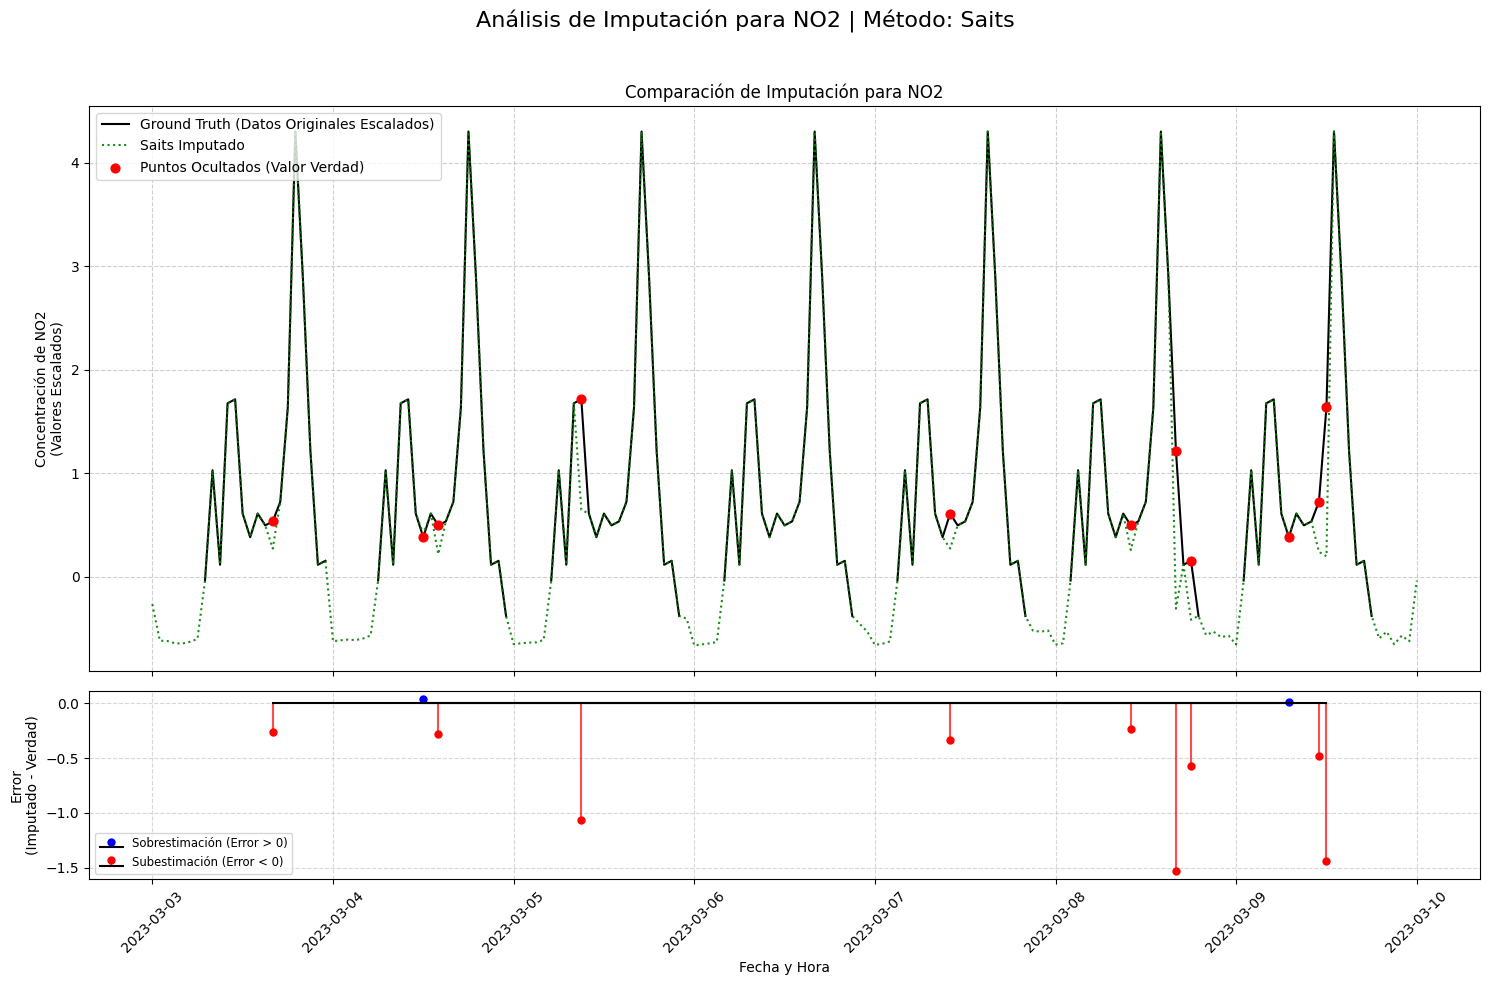


--- Generando gráfico para: PM10 ---


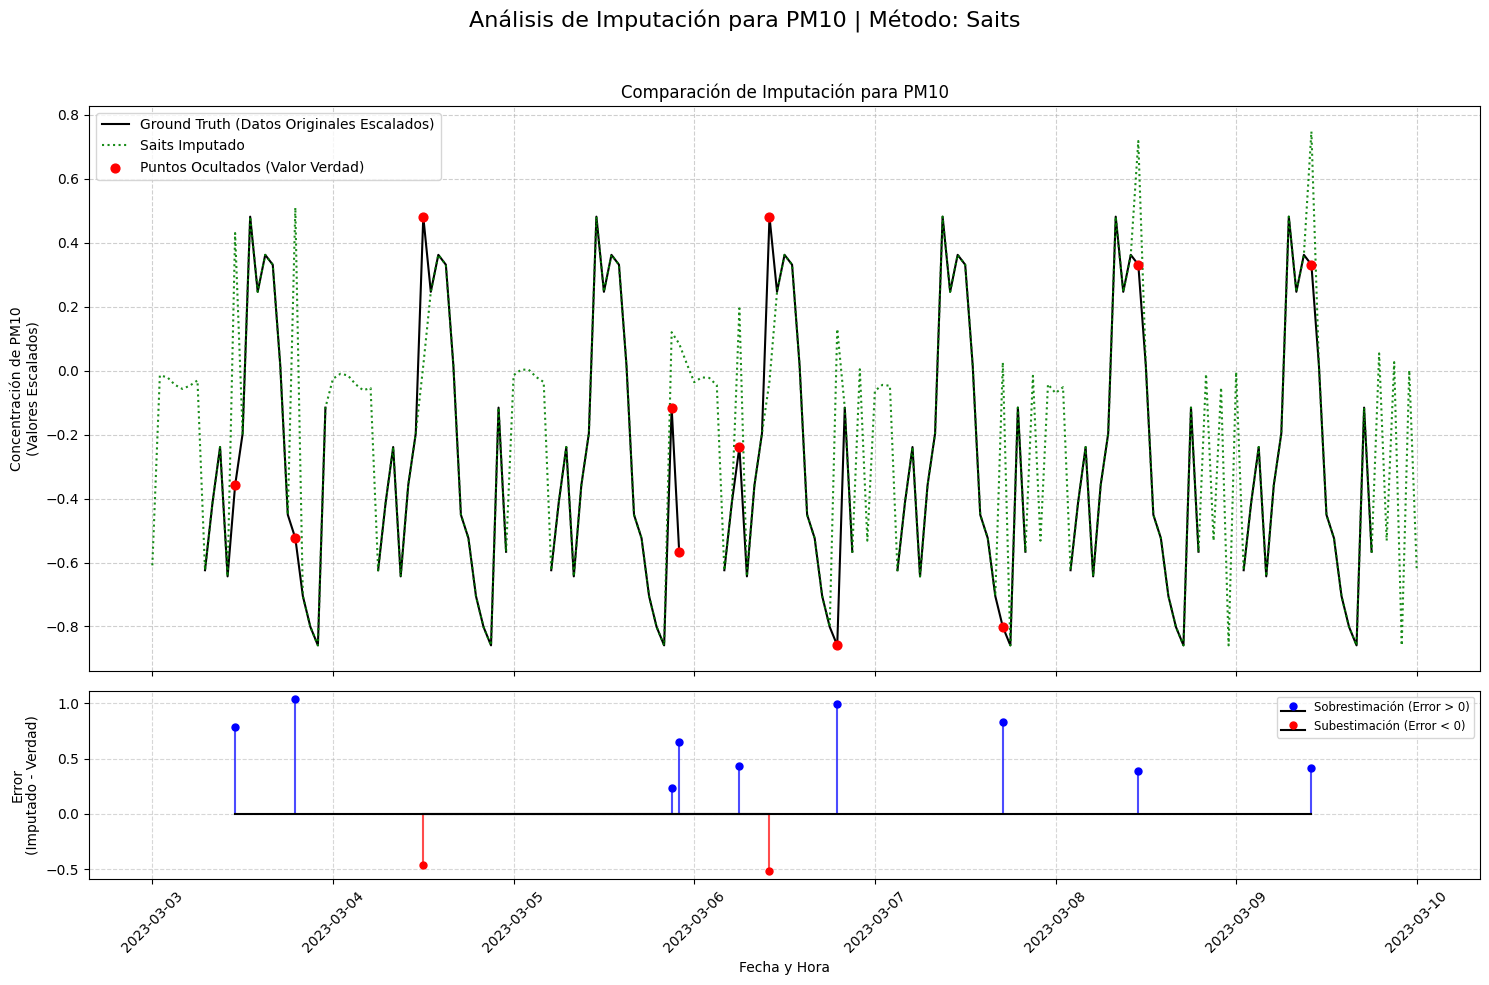


--- Generando gráfico para: O3 ---


ConversionError: Failed to convert value(s) to axis units: array([NaT, NaT], dtype=object)

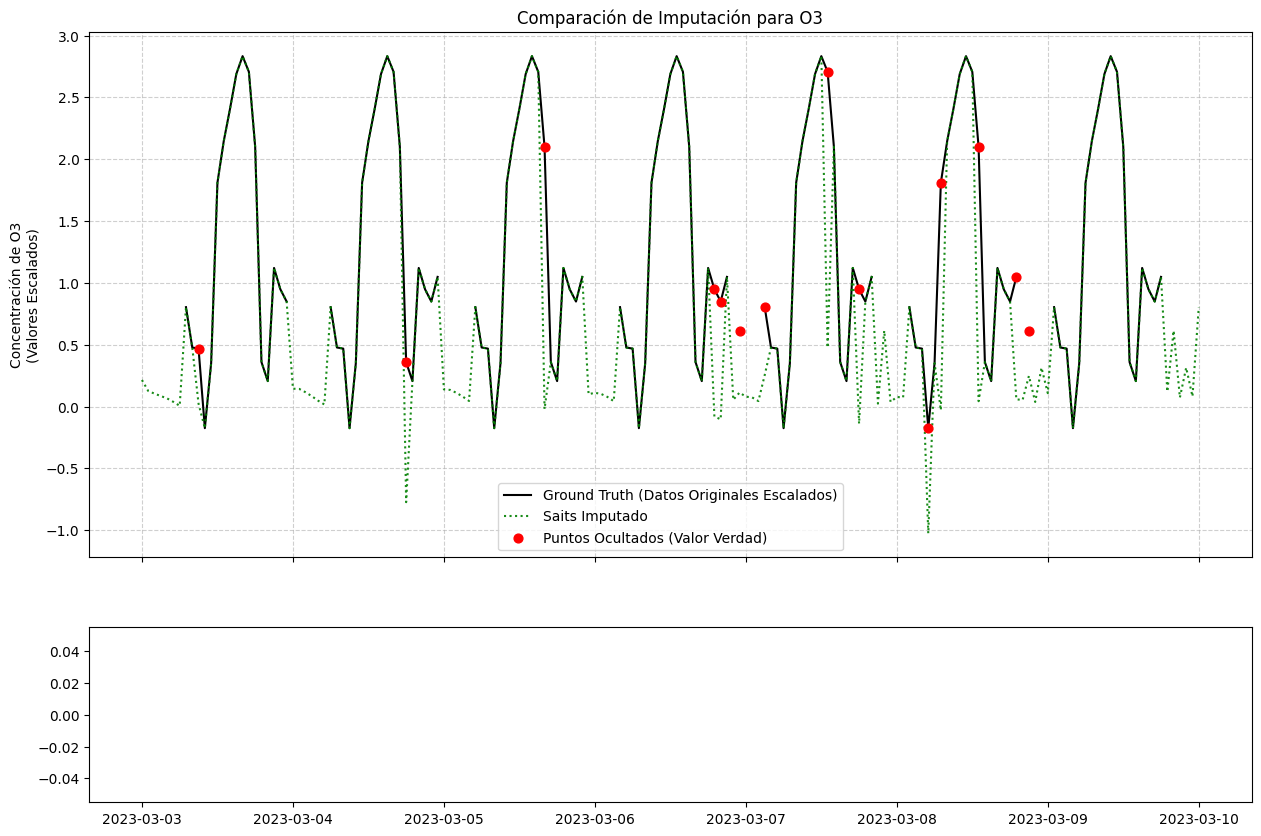

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Necesario para NaN

# --- Inicio del Código Refactorizado ---

VARIABLES_A_PLOTEAR = ["NO2", "PM10", "O3", "eBC_ff", "TEMP"]
PLOT_START_DATE = "2023-03-03 00:00:00" # Rango de fechas para el zoom
PLOT_END_DATE = "2023-03-10 00:00:00"   # Reducido para mejor visualización
IMPUTATION_METHOD_TO_PLOT = 'saits'
IMPUTED_COLOR = 'green'
IMPUTED_LINESTYLE = ':'


def plot_imputation_comparison_for_feature(
    feature_to_plot,
    plot_start_str,
    plot_end_str,
    config_obj,
    original_data_df, # periodo_1_raw
    processed_data_dict, # processed_data
    imputed_results_dict, # imputed_results
    test_data_dict, # dataset_for_testing
    utils_obj,
    method_key='saits',
    imputed_color='green',
    imputed_linestyle=':'
):
    """
    Genera un gráfico doble:
    1. Comparando el ground truth y los resultados de imputación.
    2. Mostrando la serie temporal del error de imputación.

    Args:
        (Argumentos iguales a la versión anterior)
    """
    if feature_to_plot not in config_obj.FEATURE_COLUMNS:
        print(f"Advertencia: '{feature_to_plot}' no está en config.FEATURE_COLUMNS. Saltando gráfico.")
        return

    feature_index = config_obj.FEATURE_COLUMNS.index(feature_to_plot)
    reconstruction_index = processed_data_dict['test_index']

    # --- 1. Preparar los Datos (Ground Truth e Imputados) ---
    ground_truth_df_full = utils_obj.reshape_imputed_to_df(
        test_data_dict['X_ori'], reconstruction_index, config_obj.FEATURE_COLUMNS, config_obj.N_STEPS
    )
    imputed_df_full = utils_obj.reshape_imputed_to_df(
        imputed_results_dict[method_key], reconstruction_index, config_obj.FEATURE_COLUMNS, config_obj.N_STEPS
    )
    
    # Filtrar ambas series por el rango de fechas
    ground_truth_series = ground_truth_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]
    imputed_series = imputed_df_full.loc[plot_start_str:plot_end_str, feature_to_plot]

    if ground_truth_series.empty:
        print(f"No hay datos de ground truth para {feature_to_plot} en el rango especificado.")
        return

    # --- 2. Identificar los puntos ocultos en el rango del plot ---
    mask_reshaped_flat = test_data_dict['artificial_mask'].reshape(-1, processed_data_dict['n_features'])
    mask_series_full_feature = pd.Series(mask_reshaped_flat[:, feature_index], index=ground_truth_df_full.index)
    mask_series_plot_range = mask_series_full_feature.loc[plot_start_str:plot_end_str]
    missing_indices = mask_series_plot_range[mask_series_plot_range == 1].index

    # --- 3. Calcular la Serie Temporal del Error ---
    # El error es: valor imputado - valor verdad
    # Solo existe en los 'missing_indices'
    error_series = pd.Series(np.nan, index=ground_truth_series.index, dtype='float64')
    # Nos aseguramos de calcular el error solo donde tenemos ambos valores
    valid_error_indices = missing_indices.intersection(imputed_series.index)
    error_values = imputed_series.loc[valid_error_indices] - ground_truth_series.loc[valid_error_indices]
    error_series.loc[valid_error_indices] = error_values


    # --- 4. Crear el Gráfico con 2 Subplots ---
    # Se crean dos subplots que comparten el eje X para que el zoom y el paneo estén sincronizados
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]}) # Dar más espacio al gráfico principal
    
    # --- Gráfico Superior: Comparación de Series Temporales ---
    ax1 = axes[0]
    ax1.plot(ground_truth_series.index, ground_truth_series.values,
             label='Ground Truth (Datos Originales Escalados)', color='black', linewidth=1.5)
    
    ax1.plot(imputed_series.index, imputed_series.values,
             label=f'{method_key.title()} Imputado', color=imputed_color,
             linestyle=imputed_linestyle, alpha=0.9, zorder=4)

    # Marcar los puntos originales que fueron ocultados
    ax1.scatter(missing_indices, ground_truth_series.loc[missing_indices],
                color='red', s=40, label='Puntos Ocultados (Valor Verdad)', zorder=5)

    ax1.set_title(f"Comparación de Imputación para {feature_to_plot}")
    ax1.set_ylabel(f"Concentración de {feature_to_plot}\n(Valores Escalados)")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Gráfico Inferior: Serie Temporal del Error ---
    ax2 = axes[1]

    # Separar errores positivos (sobrestimación) y negativos (subestimación) para colorear
    positive_errors = error_series[error_series > 0]
    negative_errors = error_series[error_series < 0]

    # Usar `stem` para dibujar los errores como impulsos desde el cero
    # Marcadores azules para sobreestimación
    markerline, stemlines, baseline = ax2.stem(
        positive_errors.index, positive_errors.values,
        linefmt='b-', markerfmt='bo', basefmt='k-', label='Sobrestimación (Error > 0)'
    )
    plt.setp(stemlines, 'linewidth', 1.5, 'alpha', 0.7)
    plt.setp(markerline, 'markersize', 5)

    # Marcadores rojos para subestimación
    markerline, stemlines, baseline = ax2.stem(
        negative_errors.index, negative_errors.values,
        linefmt='r-', markerfmt='ro', basefmt='k-', label='Subestimación (Error < 0)'
    )
    plt.setp(stemlines, 'linewidth', 1.5, 'alpha', 0.7)
    plt.setp(markerline, 'markersize', 5)
    
    ax2.set_ylabel("Error\n(Imputado - Verdad)")
    ax2.set_xlabel("Fecha y Hora")
    ax2.legend(fontsize='small')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # --- Finalización del Gráfico ---
    fig.suptitle(f"Análisis de Imputación para {feature_to_plot} | Método: {method_key.title()}", fontsize=16)
    plt.xticks(rotation=45)
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para el supertítulo
    plt.show()


# --- Bucle para generar los gráficos para las variables seleccionadas ---
# (Asegúrate de que las variables config, periodo_1_raw, processed_data,
# imputed_results, dataset_for_testing y utils estén definidas en tu notebook)
#
for feature in VARIABLES_A_PLOTEAR:
    print(f"\n--- Generando gráfico para: {feature} ---")
    plot_imputation_comparison_for_feature(
        feature_to_plot=feature,
        plot_start_str=PLOT_START_DATE,
        plot_end_str=PLOT_END_DATE,
        config_obj=config,
        original_data_df=periodo_1_raw,
        processed_data_dict=processed_data,
        imputed_results_dict=imputed_results,
        test_data_dict=dataset_for_testing,
        utils_obj=utils,
        method_key=IMPUTATION_METHOD_TO_PLOT,
        imputed_color=IMPUTED_COLOR,
        imputed_linestyle=IMPUTED_LINESTYLE
    )

## 9. Opcional: Guardar Resultados

Podemos guardar la tabla de evaluación y/o los datos imputados (por ejemplo, los resultados de SAITS) en archivos CSV si es necesario para análisis posteriores o informes.

In [ ]:
# Guardar la tabla de evaluación
# evaluation_table.to_csv(f"{config.RESULTS_DIR}/imputation_evaluation.csv")
# print(f"Resultados de evaluación guardados en {config.RESULTS_DIR}/imputation_evaluation.csv")

# Guardar datos imputados (ej. resultado de SAITS) si es necesario
# saits_imputed_df = utils.reshape_imputed_to_df(...) # Necesitas reconstruir el DataFrame
# saits_imputed_df.to_csv(...)

print("\nFlujo de trabajo finalizado.")